<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/PTE_DL2_ENG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning practical


## Lesson 2: TensorFlow, regression, classification, regularization
### 16 September 2026

# PTE DL2 #


- building a **fully connected** neural network architecture
- applying neural networks to two classic ML problems: **regression** and **classification**.
- training neural networks with **stochastic gradient descent**, and
- improving performance with the help of **dropout**, **batch normalization** and other techniques


# What is deep learning? #

In the field of artificial intelligence, the most impressive advances of recent years have happened in *deep learning*. Natural language translation, image recognition and games are all tasks where deep learning models have approached or even surpassed human-level performance.

What is deep learning? **Deep learning** is an approach to machine learning that is characterized by deep computational networks. It is this computational depth that allows deep learning models to unravel the complex and hierarchical patterns found in the most difficult real-world datasets.

Thanks to their performance and scalability, **neural networks** have become the defining model of deep learning. Neural networks consist of neurons, where each individual neuron performs only one simple computation. The power of neural networks comes instead from the complexity of the connections that the neurons can form.


# The neuron #

So let us start with the fundamental component of a neural network: the individual neurons. A **neuron** (or **unit**) with one input looks like this:

<figure style="padding: 1em;">
<img src="https://i.imgur.com/mfOlDR6.png" width="250" alt="Diagram of a linear unit.">
<figcaption style="textalign: center; font-style: italic"><center>The linear unit: $y = w x + b$.
</center></figcaption>
</figure>

The input is `x`. Its connection to the neuron has a **weight**, which is `w`. Whenever a value flows through a connection, we multiply the value by the weight of the connection. For the input `x` that arrives at the neuron, this is `w * x`. A neural network "learns" by modifying its weights.

`b` is a special kind of weight that we call the **bias**. No input data is connected to the bias; instead we put a `1` in the diagram, so that the value arriving at the neuron is just `b` (since `1 * b = b`). The bias allows the neuron to modify its output independently of its inputs.

`y` is the value that the neuron finally outputs. To produce the output, the neuron sums the values it received through its connections. The activation of this neuron is `y = w * x + b`, or, as a formula, $y = w x + b$.

<blockquote style="margin-right:auto; margin-left:auto; background-color: #ebf9ff; padding: 1em; margin:24px;">
    <strong>Is the formula $y=w x + b$ familiar?</strong><br>
It is the equation of a straight line! This is the slope-intercept equation, where $w$ is the slope and $b$ is the y-intercept.
</blockquote>

# Example - The linear unit as a model #

Although individual neurons usually work only as part of a larger network, it is often useful to start with the model of a single neuron as a baseline. Models consisting of a single neuron are *linear* models.

Let us think through how this could work on a dataset such as [80 Cereals](https://www.kaggle.com/crawford/80-cereals). If we train a model with `'sugars'` (grams of sugar per serving) as the input and `'calories'` (calories per serving) as the output, then the bias is `b=90` and the weight is `w=2.5`. The calories of a cereal containing 5 grams of sugar per serving can be estimated like this:

<figure style="padding: 1em;">
<img src="https://i.imgur.com/yjsfFvY.png" width="1000" alt="Calculation with the linear unit.">
<figcaption style="textalign: center; font-style: italic"><center>Calculation with the linear unit.
</center></figcaption>
</figure>

And comparing it with our formula we get $calories = 2.5 * 5 + 90 = 102.5$, exactly as expected.

# Multiple inputs #

The *80 Cereals* dataset contains many more features than just `'sugars'`. What if we wanted to extend our model with things like fiber or protein content? That is quite simple. We just add more input connections to the neuron, one for each additional feature. To find the output, we would multiply each input by its connection weight and then add them together.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/vyXSnlZ.png" width="300" alt="Three input connections: x0, x1 and x2, plus the bias.">
<figcaption style="textalign: center; font-style: italic"><center>A linear unit with three inputs.
</center></figcaption>
</figure>

The formula of this neuron would be: $y = w_0 x_0 + w_1 x_1 + w_2 x_2 + b$. A linear unit with two inputs fits a plane, and a unit with more inputs than that fits a hyperplane.

# Linear units in Keras #

In Keras, the simplest way to create a model is with `keras.Sequential`, which builds a neural network *as a set of layers*. Models like the one above can be created with a *dense layer* (which we will learn more about below).

We can define a linear model that accepts three input features (`'sugars'`, `'fiber'` and `'protein'`) and produces a single output (`'calories'`) like this:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Create a network with 1 linear unit
model = keras.Sequential([
    layers.Dense(units=1, input_shape=[3])
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We can also create the model like this, notice the function classes!!!

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(1, input_shape=[3]))

With the first argument, `units`, we specify how many outputs we would like. In this case we are predicting only `'calories'`, so we use `units=1`.

With the second argument, `input_shape`, we tell Keras the dimensions of the inputs. Setting `input_shape=[3]` ensures that the model accepts three features as input (`'sugars'`, `'fiber'` and `'protein'`).

This model is now ready to be fitted to the training data!

<blockquote style="margin-right:auto; margin-left:auto; background-color: #ebf9ff; padding: 1em; margin:24px;">
    <strong>Why is there a Python list in <code>input_shape</code>?</strong><br>
The data we will use in this course will usually be tabular data, like a Pandas dataframe. There will be one input for each feature of the dataset. Features are arranged in columns, so we will always have <code>input_shape=[num_columns]</code>.

Keras uses a list here to make more complex datasets possible. Image data, for example, may need three dimensions: <code>[height, width, channels]</code>.
</blockquote>

# Neural network

In this lesson we will look at how we can build neural networks that are able to learn the complex types of relationships that deep neural networks are famous for.

The key idea here is *modularity*, that is, building a complex network out of simpler functional units. We have seen how a linear unit computes a linear function -- now we will look at how we can combine and modify these individual units to model more complex relationships.

# Layers #

Neural networks typically organize their neurons into **layers**. If we collect together linear units that share a common input, we get a **dense** layer.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/2MA4iMV.png" width="300" alt="A stack of three circles in an input layer connected to two circles in a dense layer.">
<figcaption style="textalign: center; font-style: italic"><center>A dense layer of two linear units that receives two inputs and a bias.
</center></figcaption>
</figure>

We can also think of each layer of a neural network as performing some relatively simple transformation. Through a deep stack of layers, a neural network can transform its inputs in an increasingly complex way. In a well-trained neural network, each layer is a transformation that brings us a little closer to the solution.

<blockquote style="margin-right:auto; margin-left:auto; background-color: #ebf9ff; padding: 1em; margin:24px;">
    <strong>Many kinds of layers</strong><br>
A "layer" in Keras is a very general thing. A layer can be essentially any kind of <em>data transformation</em>. Many layers, such as the <a href="https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D">convolutional</a> and <a href="https://www.tensorflow.org/api_docs/python/tf/keras/layers/RNN">recurrent</a> layers, transform the data using neurons, and they differ mainly in the pattern of the connections they form. Others, however, are used for <a href="https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding">extracting new features</a> or merely for <a href="https://www.tensorflow.org/api_docs/python/tf/keras/layers/Add">simple arithmetic</a>. There is a whole world of layers to discover -- <a href="https://www.tensorflow.org/api_docs/python/tf/keras/layers">take a look at them</a>!
</blockquote>

# The activation function #

It turns out, however, that two dense layers with nothing in between them are no better than a single dense layer on its own. Dense layers on their own can never move us out of the world of lines and planes. What we need is something *nonlinear*. We need activation functions.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/OLSUEYT.png" width="400" alt="">
<figcaption style="textalign: center; font-style: italic"><center>Without activation functions, neural networks can only learn linear relationships. In order to fit curves, we need to use activation functions.
</center></figcaption>
</figure>

An **activation function** is simply some function that we apply to each of a layer's outputs (its *activations*). The most widespread one is the *rectifier* function $max(0, x)$.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/aeIyAlF.png" width="400" alt="Graph of the rectifier function. The line is y=x when x>0 and y=0 when x<0, which results in a 'hinged' shape like '_/'.">>
<figcaption style="textalign: center; font-style: italic"><center>
</center></figcaption>
</figure>

The graph of the rectifier function is a line whose negative part has been "rectified" to zero. Applying the function to the outputs of a neuron puts a *bend* into the data, moving away from simple lines.

If we attach the rectifier to a linear unit, we get a **rectified linear unit**, or **ReLU**. (This is why the rectifier function is usually called the "ReLU function".) Applying the ReLU activation to a linear unit means that the output will be `max(0, w * x + b)`, which we can draw on a diagram like this:

<figure style="padding: 1em;">
<img src="https://i.imgur.com/eFry7Yu.png" width="250" alt="Diagram of a single ReLU. Like a linear unit, but instead of the '+' symbol there is now a hinged '_/'.">
<figcaption style="textalign: center; font-style: italic"><center>A rectified linear unit.
</center></figcaption>
</figure>

Later in the course we will also get to know further activation functions. (sigmoid, tanh, ...)

# Stacking dense layers

Now that we have some nonlinearity, let us look at how we can stack layers on top of each other to get complex data transformations.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/Y5iwFQZ.png" width="450" alt="An input layer, two hidden layers and a final linear layer.">
<figcaption style="textalign: center; font-style: italic"><center>A set of dense layers forms a "fully connected" network.
</center></figcaption>
</figure>

The layers before the output layer are sometimes called **hidden**, since we never see their outputs directly.

Now notice that the last (output) layer is a linear unit (that is, it has no activation function). This is what makes this network suitable for a regression task, where we are trying to predict some arbitrary numerical value. Other tasks (such as classification) may require an activation function on the output.

## Building sequential models ##

The `Sequential` model we use connects a list of layers in order from first to last: the first layer receives the input and the last layer produces the output. This is how the model shown in the figure above is created:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # the hidden ReLU layers
    layers.Dense(units=4, activation='relu', input_shape=[2]),
    layers.Dense(units=3, activation='relu'),
    # the linear output layer
    layers.Dense(units=1),
])

# the model can also be built layer by layer using model.add(layers.Dense(units=3, activation='relu'))

# Introduction


As with every machine learning task, here too we start with a set of training data. Each example of the training data consists of a few features (the inputs) and an expected target value (the output). Training the network means adjusting the weights so that the network can transform the features into the target value. In the *80 Cereals* dataset, for example, we would like a network that is able to take the "sugars", "fiber" and "protein" content of each cereal into account and make a prediction about the "calories" of that cereal. If we can successfully train a network for this task, then its weights must in some way represent the relationship between the features mentioned and the target expressed in the training data.

Besides the training data, we need two more things:
- A "loss function" that measures how good the network's predictions are.
- An "optimizer" that tells the network how to change its weights.

# The loss function

We have seen how to design the architecture of a network, but we have not yet seen how to tell the network *what* problem to solve. That is the job of the loss function.

The **loss function** measures the discrepancy between the true value of the target and the value predicted by the model.

Different problems require different loss functions. We have looked at **regression** problems, where the task is to predict some numerical value -- calories in *80 Cereals*, a rating in *Red Wine Quality*. Other regression tasks might be predicting the price of a house or the fuel efficiency of a car.

A common loss function for regression problems is the **mean absolute error**, or **MAE**. For each prediction `y_pred`, the MAE measures the discrepancy from the true target `y_true` by the absolute difference `abs(y_true - y_pred)`.

The total MAE loss on a dataset is the mean of all the absolute differences.



<figure style="padding: 1em;">
<img src="https://i.imgur.com/VDcvkZN.png" width="500" alt="A graph showing the error bars from the data points to the fitted line..">
<figcaption style="textalign: center; font-style: italic"><center>The mean absolute error is the average length between the fitted curve and the data points.
</center></figcaption>
</figure>

Besides the MAE, other loss functions we may encounter for regression problems are the mean squared error (MSE) or the Huber loss (both available in Keras).

During training, the model uses the loss function as a guide to find the correct values of the weights (a lower loss is better). In other words, the loss function tells the network its goal.

# The optimizer - stochastic gradient descent

We have described the problem we want to solve with the network, but now we have to tell it *how* to solve it. That is the job of the **optimizer**. The optimizer is an algorithm that adjusts the weights so as to minimize the loss.

Practically all of the optimizer algorithms used in deep learning belong to the family called **stochastic gradient descent**. These are iterative algorithms that train the network in steps. One **step** of training proceeds as follows:
1. Sample some training data and run it through the network to make predictions.
2. Measure the loss between the predictions and the true values.
3. Finally, adjust the weights in a direction that makes the loss smaller.

Then just do this over and over again until the loss is as small as you want it to be (or until it stops decreasing).

<figure style="padding: 1em;">
<img src="https://i.imgur.com/rFI1tIk.gif" width="1600" alt="Fitting one item at a time. The loss decreases and the weights approach their true values.">
<figcaption style="textalign: center; font-style: italic"><center>Training a neural network with stochastic gradient descent.
</center></figcaption>
</figure>

The sample of training data used in each iteration is called a **minibatch** (or often just a "batch"), while one complete pass through the training data is called an **epoch**. The number of epochs we train for means how many times the network sees each training example.

The animation shows the linear model from the first part being trained with SGD. The pale red points represent the full training set, while the solid red points are the minibatches. Every time SGD sees a new minibatch, it pushes the weights (`w`, the slope, and `b`, the y-intercept) towards their correct values on that batch. From batch to batch, the line eventually converges to the best fit. You can see that the loss keeps getting smaller as the weights get closer to the true values.



## Learning rate and batch size

Notice that the line moves only a small amount in the direction of each batch (instead of moving all the way). The size of these shifts is determined by the **learning rate**. A smaller learning rate means that the network has to see more minibatches before its weights converge to their best values.

The learning rate and the size of the minibatches are the two parameters that have the greatest effect on the course of SGD training. Their interaction is often subtle, and choosing the right values for these parameters is not always obvious. (We will examine these effects in practice.)

Fortunately, for most work there will be no need for extensive hyperparameter search to get satisfactory results. **Adam** is an SGD algorithm that has an adaptive learning rate, which makes it suitable for most problems without tuning the parameters (in a certain sense it is "self-tuning"). Adam is a great general-purpose optimizer.

## Adding the loss and the optimizer

After defining the model, you can add a loss function and an optimizer with the model's `compile` method:

```
model.compile(
    optimizer="adam",
    loss="mae",
)
```

Notice that we can specify the loss and the optimizer with just a string. We can also access these directly through the Keras API -- if, for example, we wanted to tune parameters -- but for us the defaults are fine as well.

<blockquote style="margin-right:auto; margin-left:auto; background-color: #ebf9ff; padding: 1em; margin:24px;">".
    <strong>What's in a name?</strong><br>
The <strong>gradient</strong> is a vector that tells us in which direction the weights should go. More precisely, it tells us how to change the weights so that the loss changes <em>faster</em>. We call our process <strong>gradient descent</strong>, because it uses the gradient to <em>descend</em> the loss curve towards a minimum. <strong>Stochastic</strong> means "determined by chance". Our training is <em>stochastic</em> because the minibatches are <em>random samples</em> from the dataset. And that is why it is called SGD!
</blockquote>

# Example - Red wine quality

We now know everything we need in order to start training deep learning models. So let us see it in practice! We will use the *Red Wine Quality* dataset.

This dataset consists of the physicochemical measurements of about 1600 Portuguese red wines. It also contains the quality rating of each wine from blind taste tests. How well can we predict the perceived quality of a wine from these measurements?

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

red_wine = pd.read_csv('https://raw.githubusercontent.com/karsarobert/DeepLearning2026/main/red-wine.csv')

y = red_wine.quality # setting X and y
X = red_wine.drop(['quality'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) # first split into train and test sets

# Scale to [0, 1]
max_ = X_train.max(axis=0)
min_ = X_train.min(axis=0)
X_train = (X_train - min_) / (max_ - min_)
X_test = (X_test - min_) / (max_ - min_)

red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
y_train[:10]

,quality
701,6
56,5
142,6
863,5
1387,5
625,5
761,5
940,7
613,5
325,6


How many inputs should this network have? We can find this out from the number of columns of the data matrix. Be careful not to include the target (`'quality'`) here -- only the input features.

In [ ]:
X_train.shape

(1279, 11)

Eleven columns means eleven inputs.

We have chosen a three-layer network with more than 1500 neurons. This network should be able to learn fairly complex relationships in the data.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(2000, activation='relu', input_shape=[11]),
    layers.Dense(2000, activation='relu'),
    layers.Dense(2000, activation='relu'),
    layers.Dense(1),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Deciding on the architecture of a model should be part of a process. Start simply, and use the validation loss as a guide. You will learn more about model development in the practicals.

After defining the model, we set up the optimizer and the loss function.

In [ ]:
model.compile(
    optimizer='adam',
    loss='mae',
    )

We are now ready to start training! We told Keras to feed 256 rows of the training data to the optimizer at a time (the `batch_size`), and to go through the dataset 10 times (the `epochs`).

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=256,
    epochs=100,
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 379ms/step - loss: 3.1519 - val_loss: 0.8158
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0521 - val_loss: 1.1190
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9352 - val_loss: 0.6427
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7869 - val_loss: 0.8817
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8046 - val_loss: 0.6101
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6945 - val_loss: 0.6624
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6686 - val_loss: 0.5800
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6321 - val_loss: 0.5747
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6086 - val_loss: 0.6002
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6139 - val_loss: 0.5746
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5897 - val_loss: 0.5542
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5734 - val_l

You can see that Keras keeps informing you about the loss as the model learns.

Often, however, a better way to view the loss is to plot it. The `fit` method actually keeps a record of the loss produced during training in a `History` object. We convert the data into a Pandas dataframe, which makes it easier to plot.

##What do the losses mean?

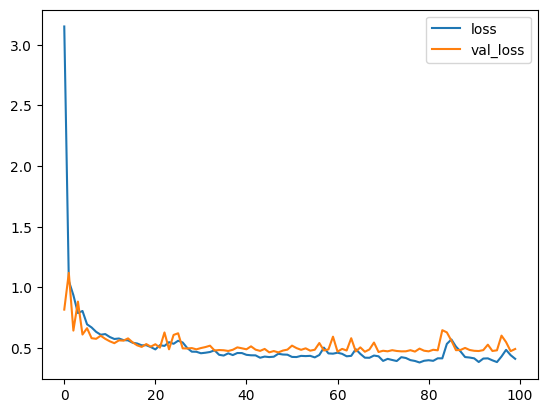

In [ ]:
import pandas as pd

# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();

Notice that the loss levels off as the epochs pass. When the loss curve becomes this flat, it means that the model has learned everything it could, and there is no point in continuing with further epochs.

#Classification task

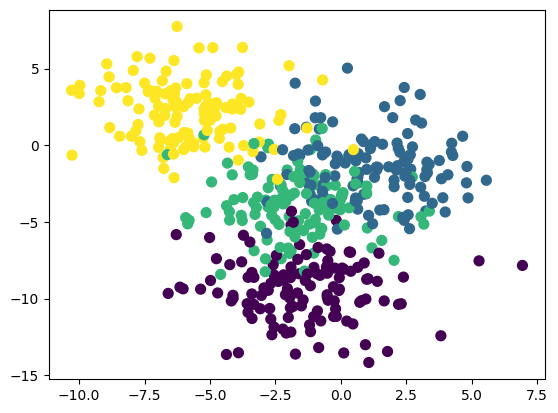

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(500, 2, centers = 4, random_state=2, cluster_std=2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50);

#Let us examine X and y

In [ ]:
print(X[:10])
print(y[:10])

[[ -0.17719387  -4.89705934]
 [ -6.49984446   3.55613952]
 [ -4.37345118 -13.64677923]
 [ -2.2818913   -7.39746205]
 [ -3.7159428   -0.02291661]
 [ -3.53530837  -1.41299822]
 [  0.58507297  -0.72268008]
 [  0.97804728  -3.16121347]
 [ -1.11658179  -3.65906656]
 [ -2.05426997  -1.61505894]]
[0 3 0 2 3 2 2 1 1 2]


#Split the data into training and test parts, and transform y using one-hot encoding

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) # first split into train and test sets

y_train = tf.keras.utils.to_categorical(y_train, 4)
y_test = tf.keras.utils.to_categorical(y_test, 4)

In [ ]:
y_train[:5]

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

#Let us build the architecture with 3 hidden layers of 64 neurons each
Pay attention to the input/output dimensions and to the activations!

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[2]),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Use compile to set the optimizer, the loss and the metric
Note: this is a classification task!

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])


#Let us fit the model

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=256,
    epochs=200,
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2850 - loss: 1.4434 - val_accuracy: 0.3600 - val_loss: 1.2848
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3675 - loss: 1.2945 - val_accuracy: 0.5400 - val_loss: 1.1507
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4825 - loss: 1.1685 - val_accuracy: 0.6900 - val_loss: 1.0475
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6800 - loss: 1.0697 - val_accuracy: 0.6900 - val_loss: 0.9683
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6600 - loss: 0.9893 - val_accuracy: 0.6700 - val_loss: 0.9065
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6450 - loss: 0.9229 - val_accuracy: 0.6600 - val_loss: 0.8604
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6475 - loss: 0.8685 - val_accuracy: 0.6500 - val_loss: 0.8236
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6650 - loss: 0.8235 - val_accuracy: 0.6700 - val_loss: 0

#Let us look at the losses!

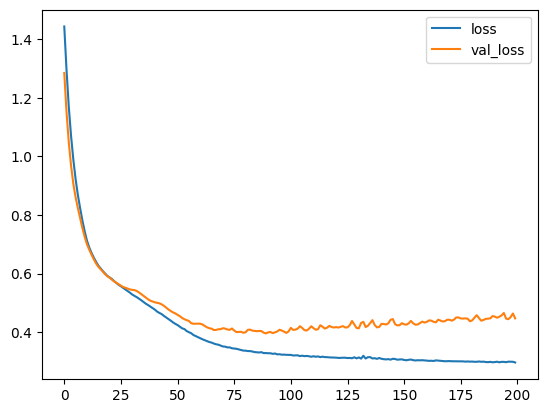

In [ ]:
import pandas as pd

# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();

In [ ]:
import numpy as np

rng = np.random.RandomState(0) # generate random points around the training data
Xnew = [-15,-15]+ [25, 25] * rng.rand(2000,2)
ynew = model.predict(Xnew)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


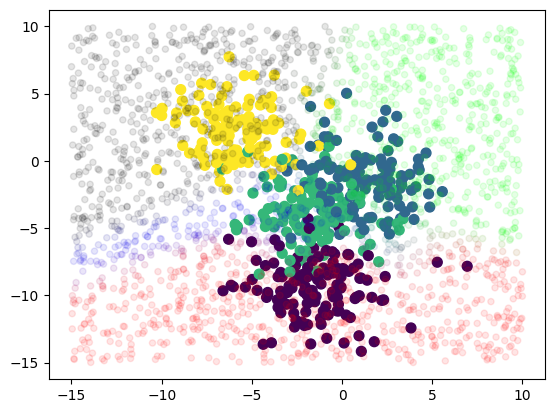

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50) #plot the training data
lim = plt.axis() # the training data define the limits of the plot
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=20, alpha=0.1) # plot the test points
#plt.axis(lim);

# Introduction

Recall from the example of the previous task that Keras keeps a history of the training and validation loss over the epochs while it trains the model. In this part we will learn how to interpret these learning curves and how we can use them to guide model development. In particular, we will examine the learning curves for evidence of *underfitting* and *overfitting*, and we will look at a few strategies for correcting these.

# Interpreting the learning curves

You can think of the information in the training data in two ways: *signal* and *noise*. The signal is the part that generalizes, the part that can help our model make predictions from new data. The noise is the part that is true *only* of the training data; the noise is all the random fluctuation that comes from the data of the real world, or all the random, uninformative patterns that in reality cannot help the model make predictions. The noise is the part that may look useful but in fact is not.

We train the model by choosing weights or parameters that minimize the loss on a training set. You may know, however, that in order to evaluate a model's performance accurately, we have to evaluate it on a new set of data, the *validation* data.

When we train a model, we plot the loss per epoch on the training set. On top of that we also plot the validation data. These plots are called **learning curves**. In order to train deep learning models effectively, we have to be able to interpret them.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/tHiVFnM.png" width="500" alt="A plot of the training and validation loss.">
<figcaption style="textalign: center; font-style: italic"><center>The validation loss gives an estimate of the expected error on unseen data.
</center></figcaption>
</figure>

Now, the training loss decreases either when the model learns signal or when it learns noise. The validation loss, however, will only decrease when the model learns signal. (Whatever noise the model has learned from the training set will not generalize to new data.) So, when the model learns signal, both curves decrease, but when it learns noise, a *gap* opens up between the curves. The size of the gap shows how much noise the model has learned.

Ideally, we would create models that learn all of the signal and none of the noise. In practice this will never happen. Instead we make a kind of trade. We can push the model to learn more signal at the cost of learning more noise. As long as the trade is to our advantage, the validation loss continues to decrease. After a certain point, however, the trade can turn against us, the cost exceeds the benefit, and the validation loss starts to rise.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/eUF6mfo.png" width="600" alt="Two graphs. On the left, a line through a few data points with the true fit a parabola. On the right, a curve running through each datapoint with the true fit a parabola.">
<figcaption style="textalign: center; font-style: italic"><center>Underfitting and overfitting.
</center></figcaption>
</figure>

This trade-off indicates that two problems can arise while training a model: not enough signal or too much noise. **Underfitting** on the training set is when the loss is not as low as it could be, because the model has not learned enough *signal*. **Overfitting** on the training set is when the loss is not as low as it could be, because the model has learned too much *noise*. The trick to training deep learning models is finding the best balance between the two.

We will look at a few methods for getting more signal out of the training data while reducing the amount of noise.

# Capacity

The **capacity** of a model refers to the size and complexity of the patterns it is able to learn. In the case of neural networks, this is largely determined by how many neurons it has and how they are connected. If it appears that the network is not fitting the data well, then try increasing its capacity.

You can increase the capacity of a network by making it *wider* (more units in the existing layers) or *deeper* (by adding more layers). **Wider networks learn more linear relationships more easily, while deeper networks prefer the more nonlinear ones.** Which one is better depends only on the dataset.

```
model = keras.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

wider = keras.Sequential([
    layers.Dense(32, activation='relu'),
    layers.Dense(1),
])

deeper = keras.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])
```


# Early stopping
We have mentioned that if a model learns the noise too eagerly, the validation loss may start to increase during training. To prevent this, we can simply stop the training when it appears that the validation loss is no longer decreasing. Interrupting the training in this way is called **early stopping**.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/eP0gppr.png" width=500 alt="A plot of the learning curves with early stopping at the minimum validation loss, underfitting to the left and overfitting to the right.">.
<figcaption style="textalign: center; font-style: italic"><center>We keep the model where the validation loss is at its minimum.
</center></figcaption>
</figure>

As soon as we detect that the validation loss has started to rise, we can restore the weights to the point where the minimum occurred. This ensures that the model does not keep learning noise and does not overfit the data.

Training with early stopping also means that there is less danger of stopping the training too early, before the network has finished learning the signal. So, besides preventing the overfitting that comes from training for too long, early stopping can also prevent the *underfitting* that comes from training for too short a time. Just set the number of training epochs to some large number (more than you will need), and early stopping will take care of the rest.

## Adding early stopping

In Keras we insert early stopping into our training through a callback. A **callback** is simply a function that we want to run from time to time while the network is training. The early stopping callback runs after every epoch. (Keras has [many useful callbacks](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks) predefined, but we can also [define our own](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/LambdaCallback).)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)

These parameters say: "If the validation loss has not improved by at least 0.001 compared with the previous 20 epochs, then stop the training and keep the model that was found to be the best." Sometimes it can be difficult to tell whether the validation loss is rising because of overfitting or merely because of random batch variation. The parameters let us set some tolerance for when to stop.

As we will see in our example, we pass this callback to the `fit` method along with the loss and the optimizer.

# Example - Training a model with early stopping

Let us continue developing the model from the most recent demonstration. Let us increase the capacity of the network, but in order to prevent overfitting we also add an early stopping callback.

Here is the data preparation again.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

red_wine = pd.read_csv('https://raw.githubusercontent.com/karsarobert/DeepLearning2026/main/red-wine.csv')

y = red_wine.quality # setting X and y
X = red_wine.drop(['quality'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) # first split into train and test sets

# Scale to [0, 1]
max_ = X_train.max(axis=0)
min_ = X_train.min(axis=0)
X_train = (X_train - min_) / (max_ - min_)
X_test = (X_test - min_) / (max_ - min_)

red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
#import tensorflow as tf
#y.describe()
#y.unique()
#y_train = tf.keras.utils.to_categorical(y_train)
#y_test = tf.keras.utils.to_categorical(y_test)

In [ ]:
y_train

,quality
701,6
56,5
142,6
863,5
1387,5
...,...
715,6
905,5
1096,6
235,6


In [ ]:
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
701,0.212389,0.363014,0.02,0.082759,0.090301,0.098592,0.069853,0.523495,0.574803,0.203593,0.169231
56,0.495575,0.205479,0.57,0.172414,0.096990,0.042254,0.014706,0.516153,0.236220,0.179641,0.184615
142,0.053097,0.150685,0.00,0.062069,0.063545,0.366197,0.209559,0.112335,0.740157,0.275449,0.861538
863,0.230088,0.342466,0.06,0.110345,0.110368,0.225352,0.286765,0.542584,0.606299,0.119760,0.200000
1387,0.247788,0.356164,0.07,0.062069,0.147157,0.098592,0.062500,0.442731,0.440945,0.149701,0.184615


Now let us increase the capacity of the network. We choose a fairly large network, but we rely on the callback to stop the training as soon as the validation loss shows signs of increasing.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks

early_stopping = callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=[11]),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1),
])
model.compile(
    optimizer='adam',
    loss='mae',
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Once you have defined the callback, add it as an argument in `fit` (there can be more than one, so put it in a list). When using early stopping, choose a large number of epochs, more than you will need.

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 434ms/step - loss: 5.0132 - val_loss: 3.6166
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.0987 - val_loss: 1.9003
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.5439 - val_loss: 0.7767
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1016 - val_loss: 0.9700
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8593 - val_loss: 0.9298
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8517 - val_loss: 0.6895
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7802 - val_loss: 0.6303
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7144 - val_loss: 0.6368
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6932 - val_loss: 0.6224
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6687 - val_loss: 0.6114
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6437 - val_loss: 0.5971
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6383 - val_l

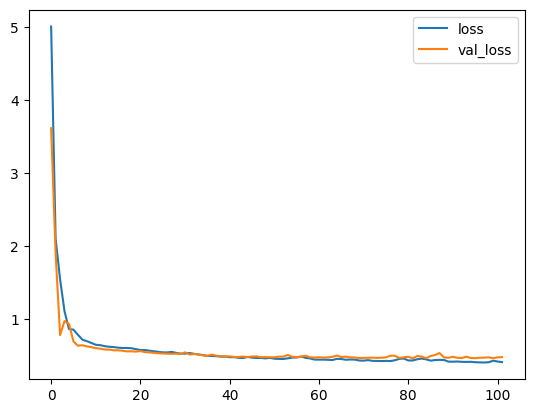

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=256,
    epochs=500,
    callbacks=[early_stopping], # put your callbacks in a list
    verbose=1,  # 0 turn off training log
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();
print("Minimum validation loss: {}".format(history_df['val_loss'].min()))

And indeed, Keras stopped the training well before the full 500 epochs!

In [ ]:
model.predict(np.array([0.362832,0.349315,0.234,0.3456,0.123,0.112551,1,1,1,1,1]).reshape(1,-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


array([[5.999516]], dtype=float32)

# Introduction

The world of deep learning is more than dense layers. You can add dozens of kinds of layers to a model. (Try browsing the [Keras docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/) for an example!) Some of them are like dense layers and define connections between neurons, while others can perform preprocessing or other kinds of transformations.

In this part we will get to know two special kinds of layers that do not themselves contain neurons, but add functionality that can sometimes be advantageous to a model in different ways. Both are often used in modern architectures.

# Dropout

The first of these is the "dropout layer", which can help to correct overfitting.

In the previous part we talked about how overfitting is caused by the network learning spurious patterns in the training data. To recognize these spurious patterns, the network often relies on very specific weight combinations, a kind of "conspiracy" of the weights.
A fully connected layer uses up most of the parameters, so during training the neurons develop co-dependencies among themselves, which holds back the individual performance of each neuron and leads to excessive fitting of the training data. Because they are so specific, they are usually fragile: if we remove one, the conspiracy falls apart.

This is the idea behind **dropout**. To break up such conspiracies, at every step of training a fraction of the layer's input units is randomly *dropped out*, which makes it much harder for the network to learn these spurious patterns in the training data. Instead it has to look for broad, general patterns, whose weight patterns are usually more robust.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/a86utxY.gif" width="600" alt="An animation of a network cycling through various random dropout configurations.">
<figcaption style="textalign: center; font-style: italic"><center>Here, 50% dropout has been added between the two hidden layers.</center></figcaption>
</figure>

You can also think of dropout as creating a kind of *ensemble* of networks. The predictions will no longer be made by one large network, but by a committee of smaller networks. The individuals in the committee tend to make different errors, but they will also tend to be right at the same time, so the committee as a whole is better than any of the individuals. (If you know random forests as an ensemble of decision trees, then this is the same idea.)

## Adding dropout

In Keras, the dropout rate argument `rate` determines what percentage of the input units are to be turned off. We place the `Dropout` layer directly before the layer to which we want to apply dropout:

```
keras.Sequential([
    # ...
    layers.Dropout(rate=0.3), # apply 30% dropout to the next layer
    layers.Dense(16),
    # ...
])
```

# Batch normalization

The next special layer we will look at performs "batch normalization" (or "batchnorm"), which can help to correct slow or unstable training.

**Batch normalization applies a transformation that keeps the average output close to 0 and the output standard deviation close to 1.**

In neural networks it is usually a good idea to put all of the data on a common scale, perhaps with something like the scikit-learn [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) or [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html). The reason is that SGD shifts the network weights in proportion to the size of the activations that the data produces. Features that tend to produce activations of very different sizes can result in unstable training behaviour.

Well, if it is good to normalize the data before it enters the network, then perhaps normalization inside the network would be even better! In fact we have a special layer that can do this, the **batch normalization layer**. The batch normalizing layer examines each batch as it arrives, first normalizes the batch with its own mean and standard deviation, and then also puts the data on a new scale using two trainable rescaling parameters. Batchnorm actually performs a kind of coordinated rescaling of its inputs.

Batchnorm is most often added as an aid to the optimization process (although it can sometimes help the prediction performance as well). Models with batchnorm usually need fewer epochs to finish training. Besides this, batchnorm can also cure various problems that can make training "get stuck". Consider adding batch normalization to your models, especially if problems arise during training.

## Adding batch normalization

It seems that batch normalization can be used at almost any point in the network. We can place it after a layer...

```
layers.Dense(16, activation='relu'),
layers.BatchNormalization(),
```

... or between a layer and its activation function:

```
layers.Dense(16),
layers.BatchNormalization(),
layers.Activation('relu'),
```

And if you add it as the first layer of your network, then it can work as a kind of adaptive preprocessing and can replace, for example, the "StandardScaler" of Sci-Kit Learn.

# Example - Using dropout and batch normalization

Let us continue developing the *Red Wine* model. Now we will increase the capacity even further, but we add dropout to check overfitting and batch normalization to speed up optimization. This time we also leave out the standardization of the data, in order to demonstrate how batch normalization can stabilize training.

When adding dropout, you may need to increase the number of units in the "Dense" layers.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    layers.Dense(1024, activation='relu', input_shape=[11]),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


This time there is no need to change the structure of the training.

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 987ms/step - loss: 5.5652 - val_loss: 5.3309
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5.3307 - val_loss: 5.1509
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5.1092 - val_loss: 4.9130
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.8651 - val_loss: 4.3744
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4.5649 - val_loss: 3.8595
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.2494 - val_loss: 3.1288
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4.0352 - val_loss: 2.5178
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.5989 - val_loss: 2.3297
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.2617 - val_loss: 2.0376
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.8643 - val_loss: 1.9324
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.5448 - val_loss: 1.7416
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.2649 - val_

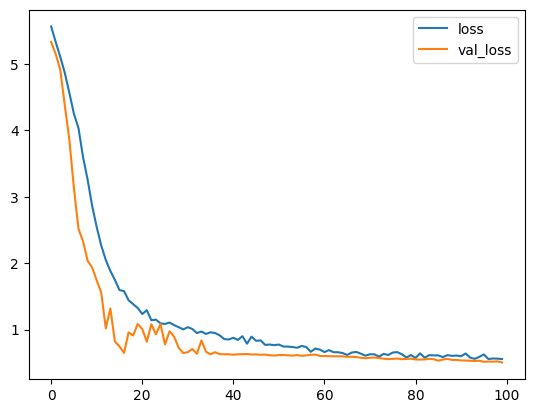

In [ ]:
model.compile(
    optimizer='adam',
    loss='mae',
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=256,
    epochs=100,
    verbose=1,
)


# Show the learning curves
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();

Typically you can achieve better performance if you standardize your data before using it for training. The fact that we were able to use the raw data at all, however, shows how effective batch normalization can be on more difficult datasets.

# Binary classification

So far in the course we have learned about how neural networks solve regression problems. Now we will apply neural networks to another common machine learning problem: classification. Most of what we have learned so far still holds. The main difference is in the loss function we use, and in the outputs we want the last layer to produce.


Classifying into one of two classes is a common machine learning problem. We might predict whether a customer is likely to buy or not, whether a credit card transaction was fraudulent or not, whether deep space signals indicate a new planet, or whether a medical test shows evidence of a disease. These are all **binary classification** problems.

In the raw data, the classes may be represented by strings such as "Yes" and "No", or "Dog" and "Cat". Before using the data, we assign an **class label**: one class becomes "0" and the other becomes "1". Assigning numerical labels brings the data into a form that the neural network can use.

# Accuracy and cross-entropy

**Accuracy** is one of the many metrics used to measure the success of a classification problem. Accuracy is the ratio of correct predictions to all predictions: `Accuracy = number_correct / total`. A model that always predicts correctly would have an accuracy of `1.0`. All other things being equal, accuracy is a reasonable metric when the classes occur with roughly the same frequency in the dataset.

The problem with accuracy (and with most other classification metrics) is that it cannot be used as a loss function. SGD needs a loss function that changes smoothly, but accuracy, being a ratio of counts, changes in "jumps". We therefore have to choose a substitute function to play the role of the loss function. This substitute is the *cross-entropy* function.

Recall that the loss function determines the *goal* of the network during training. With regression, our goal was to minimize the distance between the expected result and the predicted result. We chose the MAE to measure this distance.

With classification, we instead want the distance between *probabilities*, and cross-entropy provides that. **Cross-entropy** is a kind of measure of the distance between one probability distribution and another.




<figure style="padding: 1em;">
<img src="https://i.imgur.com/DwVV9bR.png" width="400" alt="Graphs of accuracy and cross-entropy.">
<figcaption style="textalign: center; font-style: italic"><center>Cross-entropy penalizes incorrect probability predictions.</center></figcaption>
</figure>

The idea is that we want our network to predict the correct class with a probability of 1.0. The further the predicted probability is from `1.0`, the larger the cross-entropy loss will be.

The technical reasons for using cross-entropy are a little complicated, but the most important thing to take away from this section is the following: use cross-entropy as the classification loss; the other metrics that may be important (such as accuracy) will improve along with it.

# Producing probabilities with the sigmoid function

Both the cross-entropy and the accuracy functions require probabilities as input, that is, numbers between 0 and 1. In order to turn the real-valued outputs produced by the dense layer into probabilities, we attach a new kind of activation function, the **sigmoid activation**.

<figure style="padding: 1em;">
<img src="https://i.imgur.com/FYbRvJo.png" width="400" alt="The sigmoid graph is an 'S' shape with horizontal asymptotes at 0 to the left and 1 to the right. ">
<figcaption style="textalign: center; font-style: italic"><center>The sigmoid function maps real numbers into the interval $[0, 1]$.</center></figcaption>
</figure>

For the final class prediction we define a *threshold* probability. This is usually 0.5, so that by rounding we get the correct class: a value below 0.5 indicates the class labelled 0, and a value of 0.5 or above indicates the class labelled 1. The threshold of 0.5 is what Keras uses by default with the [accuracy metric](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/BinaryAccuracy).